<a id="table-of-contents"></a>  
# 📖 Table of Contents  
- [💬 Problem Statement](#problem-statement)  
- [📦 Data Loading](#data-loading)  
- [🧼 Text Cleaning & Parsing](#text-cleaning)  
- [🧮 Vectorization (BoW / TF-IDF)](#vectorization)  
- [🤖 Model Training (Classification)](#model-training)  
- [📊 Evaluation & Interpretation](#evaluation)  
___


<a id="problem-statement"></a>  
# 💬 Problem Statement
Sentiment Analysis for Yelp Reviews

You are a data scientist at a local business analytics firm helping small restaurants monitor their brand reputation online.

You’ve received a dataset of thousands of customer reviews scraped from Yelp. Your goal is to **train a binary sentiment classifier** that can automatically flag reviews as **positive** or **negative**, so that restaurant managers can be alerted to poor experiences in real-time and engage with customers proactively.

Key goals:
- Build a clean, generalizable pipeline
- Evaluate performance using classification metrics
- Understand top words driving sentiment predictions

[Back to the top](#table-of-contents)
___


<a id="data-loading"></a>  
# 📦 Data Loading


In [26]:
# General Libraries
import io
import re
import string
import numpy as np
import pandas as pd
from collections import Counter
from itertools import combinations
from scipy.sparse import hstack, csr_matrix
from scipy import sparse

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pyLDAvis

# NLTK
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.chunk import ChunkParserI
from nltk import pos_tag
from nltk.tokenize import TreebankWordTokenizer

# SpaCy
import spacy

# Gensim
import gensim.downloader as api
from gensim.models import CoherenceModel, Word2Vec
from gensim.corpora import Dictionary

# Sentence Transformers
from sentence_transformers import SentenceTransformer, util

# Pickle
import pickle

# Scikit-learn - Feature Extraction & Decomposition
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation, NMF, PCA

# Scikit-learn - Preprocessing & Similarity
from sklearn.preprocessing import LabelBinarizer, normalize
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Scikit-learn - Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

# Scikit-learn - Model Training & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

# Clustering & Manifold
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# XGBoost
from xgboost import XGBClassifier

# Pandas display setting
pd.set_option('display.max_colwidth', None)

In [2]:
# Load the dataset
df = pd.read_csv("../datasets/yelp.csv")
df['label'] = df['stars'].apply(lambda x: 1 if x >= 4 else 0) # ('negative' if x <= 2 else 'neutral')
df = df[["text","label"]]

# Preview the data
print(df.shape)
df.head()

(10000, 2)


,text,label
0,"My wife took me here on my birthday for breakfast and it was excellent. The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure. Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning. It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary. It was phenomenal and simply the best I've ever had. I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it. It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious. It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete. It was the best ""toast"" I've ever had.\n\nAnyway, I can't wait to go back!",1
1,"I have no idea why some people give bad reviews about this place. It goes to show you, you can please everyone. They are probably griping about something that their own fault...there are many people like that.\n\nIn any case, my friend and I arrived at about 5:50 PM this past Sunday. It was pretty crowded, more than I thought for a Sunday evening and thought we would have to wait forever to get a seat but they said we'll be seated when the girl comes back from seating someone else. We were seated at 5:52 and the waiter came and got our drink orders. Everyone was very pleasant from the host that seated us to the waiter to the server. The prices were very good as well. We placed our orders once we decided what we wanted at 6:02. We shared the baked spaghetti calzone and the small ""Here's The Beef"" pizza so we can both try them. The calzone was huge and we got the smallest one (personal) and got the small 11"" pizza. Both were awesome! My friend liked the pizza better and I liked the calzone better. The calzone does have a sweetish sauce but that's how I like my sauce!\n\nWe had to box part of the pizza to take it home and we were out the door by 6:42. So, everything was great and not like these bad reviewers. That goes to show you that you have to try these things yourself because all these bad reviewers have some serious issues.",1
2,love the gyro plate. Rice is so good and I also dig their candy selection :),1
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!! It's very convenient and surrounded by a lot of paths, a desert xeriscape, baseball fields, ballparks, and a lake with ducks.\n\nThe Scottsdale Park and Rec Dept. does a wonderful job of keeping the park clean and shaded. You can find trash cans and poopy-pick up mitts located all over the park and paths.\n\nThe fenced in area is huge to let the dogs run, play, and sniff!",1
4,"General Manager Scott Petello is a good egg!!! Not to go into detail, but let me assure you if you have any issues (albeit rare) speak with Scott and treat the guy with some respect as you state your case and I'd be surprised if you don't walk out totally satisfied as I just did. Like I always say..... ""Mistakes are inevitable, it's how we recover from them that is important""!!!\n\nThanks to Scott and his awesome staff. You've got a customer for life!! .......... :^)",1


<a id="label-distribution"></a>  
#### 📊 Label Balance

<Axes: title={'center': 'Label Distribution'}, xlabel='label'>

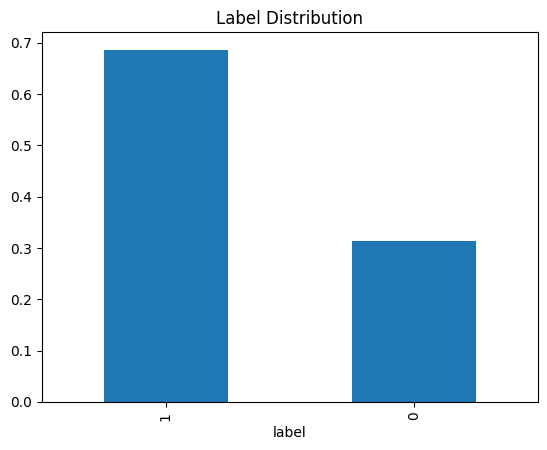

In [3]:
df['label'].value_counts(normalize=True).plot(kind='bar', title='Label Distribution')

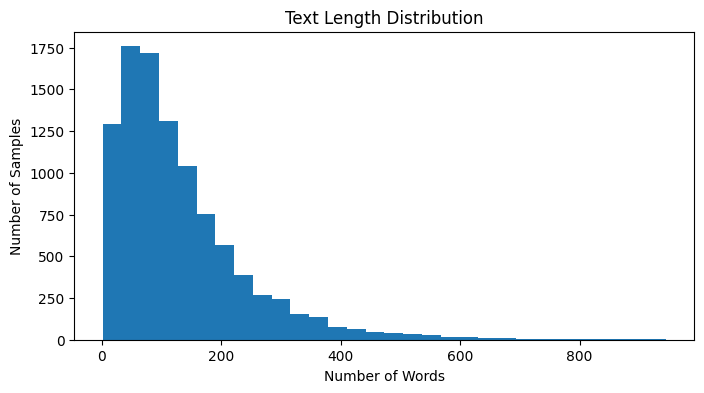

In [4]:
plt.figure(figsize=(8, 4))
df['text'].apply(lambda x: len(x.split())).hist(bins=30)
plt.xlabel("Number of Words")
plt.ylabel("Number of Samples")
plt.title("Text Length Distribution")
plt.grid(False)
plt.show()

[Back to the top](#table-of-contents)
___


<a id="text-cleaning"></a>  
# 🧼 Text Cleaning & Parsing


#### 🔤 Lowercasing and Normalization  
<a id="lowercasing"></a>  

In [5]:
# Lowercasing text column
df['text'] = df['text'].str.lower()
df.head()

# Show before and after for a single row
# print("Original:", df['text'].iloc[0])
# print("Lowercased:", df['text_lower'].iloc[0])


,text,label
0,"my wife took me here on my birthday for breakfast and it was excellent. the weather was perfect which made sitting outside overlooking their grounds an absolute pleasure. our waitress was excellent and our food arrived quickly on the semi-busy saturday morning. it looked like the place fills up pretty quickly so the earlier you get here the better.\n\ndo yourself a favor and get their bloody mary. it was phenomenal and simply the best i've ever had. i'm pretty sure they only use ingredients from their garden and blend them fresh when you order it. it was amazing.\n\nwhile everything on the menu looks excellent, i had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious. it came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete. it was the best ""toast"" i've ever had.\n\nanyway, i can't wait to go back!",1
1,"i have no idea why some people give bad reviews about this place. it goes to show you, you can please everyone. they are probably griping about something that their own fault...there are many people like that.\n\nin any case, my friend and i arrived at about 5:50 pm this past sunday. it was pretty crowded, more than i thought for a sunday evening and thought we would have to wait forever to get a seat but they said we'll be seated when the girl comes back from seating someone else. we were seated at 5:52 and the waiter came and got our drink orders. everyone was very pleasant from the host that seated us to the waiter to the server. the prices were very good as well. we placed our orders once we decided what we wanted at 6:02. we shared the baked spaghetti calzone and the small ""here's the beef"" pizza so we can both try them. the calzone was huge and we got the smallest one (personal) and got the small 11"" pizza. both were awesome! my friend liked the pizza better and i liked the calzone better. the calzone does have a sweetish sauce but that's how i like my sauce!\n\nwe had to box part of the pizza to take it home and we were out the door by 6:42. so, everything was great and not like these bad reviewers. that goes to show you that you have to try these things yourself because all these bad reviewers have some serious issues.",1
2,love the gyro plate. rice is so good and i also dig their candy selection :),1
3,"rosie, dakota, and i love chaparral dog park!!! it's very convenient and surrounded by a lot of paths, a desert xeriscape, baseball fields, ballparks, and a lake with ducks.\n\nthe scottsdale park and rec dept. does a wonderful job of keeping the park clean and shaded. you can find trash cans and poopy-pick up mitts located all over the park and paths.\n\nthe fenced in area is huge to let the dogs run, play, and sniff!",1
4,"general manager scott petello is a good egg!!! not to go into detail, but let me assure you if you have any issues (albeit rare) speak with scott and treat the guy with some respect as you state your case and i'd be surprised if you don't walk out totally satisfied as i just did. like i always say..... ""mistakes are inevitable, it's how we recover from them that is important""!!!\n\nthanks to scott and his awesome staff. you've got a customer for life!! .......... :^)",1


#### ✨ Punctuation & Special Character Removal  
<a id="punctuation-removal"></a>  



In [6]:
# Remove punctuation
df['text'] = df['text'].str.replace(f"[{re.escape(string.punctuation)}]", "", regex=True)
df.head()

,text,label
0,my wife took me here on my birthday for breakfast and it was excellent the weather was perfect which made sitting outside overlooking their grounds an absolute pleasure our waitress was excellent and our food arrived quickly on the semibusy saturday morning it looked like the place fills up pretty quickly so the earlier you get here the better\n\ndo yourself a favor and get their bloody mary it was phenomenal and simply the best ive ever had im pretty sure they only use ingredients from their garden and blend them fresh when you order it it was amazing\n\nwhile everything on the menu looks excellent i had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious it came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete it was the best toast ive ever had\n\nanyway i cant wait to go back,1
1,i have no idea why some people give bad reviews about this place it goes to show you you can please everyone they are probably griping about something that their own faultthere are many people like that\n\nin any case my friend and i arrived at about 550 pm this past sunday it was pretty crowded more than i thought for a sunday evening and thought we would have to wait forever to get a seat but they said well be seated when the girl comes back from seating someone else we were seated at 552 and the waiter came and got our drink orders everyone was very pleasant from the host that seated us to the waiter to the server the prices were very good as well we placed our orders once we decided what we wanted at 602 we shared the baked spaghetti calzone and the small heres the beef pizza so we can both try them the calzone was huge and we got the smallest one personal and got the small 11 pizza both were awesome my friend liked the pizza better and i liked the calzone better the calzone does have a sweetish sauce but thats how i like my sauce\n\nwe had to box part of the pizza to take it home and we were out the door by 642 so everything was great and not like these bad reviewers that goes to show you that you have to try these things yourself because all these bad reviewers have some serious issues,1
2,love the gyro plate rice is so good and i also dig their candy selection,1
3,rosie dakota and i love chaparral dog park its very convenient and surrounded by a lot of paths a desert xeriscape baseball fields ballparks and a lake with ducks\n\nthe scottsdale park and rec dept does a wonderful job of keeping the park clean and shaded you can find trash cans and poopypick up mitts located all over the park and paths\n\nthe fenced in area is huge to let the dogs run play and sniff,1
4,general manager scott petello is a good egg not to go into detail but let me assure you if you have any issues albeit rare speak with scott and treat the guy with some respect as you state your case and id be surprised if you dont walk out totally satisfied as i just did like i always say mistakes are inevitable its how we recover from them that is important\n\nthanks to scott and his awesome staff youve got a customer for life,1


#### 🧪 Regex Based Cleaning  
<a id="regex-cleaning"></a>  


In [7]:
# None for this example

# df['text_cleaned'] = df['text_no_punct'].str.replace(r"http\S+|www\S+|https\S+", "", regex=True)
df['text'] = df['text'].str.replace(r"\s+", " ", regex=True).str.strip()
df.head()

,text,label
0,my wife took me here on my birthday for breakfast and it was excellent the weather was perfect which made sitting outside overlooking their grounds an absolute pleasure our waitress was excellent and our food arrived quickly on the semibusy saturday morning it looked like the place fills up pretty quickly so the earlier you get here the better do yourself a favor and get their bloody mary it was phenomenal and simply the best ive ever had im pretty sure they only use ingredients from their garden and blend them fresh when you order it it was amazing while everything on the menu looks excellent i had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious it came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete it was the best toast ive ever had anyway i cant wait to go back,1
1,i have no idea why some people give bad reviews about this place it goes to show you you can please everyone they are probably griping about something that their own faultthere are many people like that in any case my friend and i arrived at about 550 pm this past sunday it was pretty crowded more than i thought for a sunday evening and thought we would have to wait forever to get a seat but they said well be seated when the girl comes back from seating someone else we were seated at 552 and the waiter came and got our drink orders everyone was very pleasant from the host that seated us to the waiter to the server the prices were very good as well we placed our orders once we decided what we wanted at 602 we shared the baked spaghetti calzone and the small heres the beef pizza so we can both try them the calzone was huge and we got the smallest one personal and got the small 11 pizza both were awesome my friend liked the pizza better and i liked the calzone better the calzone does have a sweetish sauce but thats how i like my sauce we had to box part of the pizza to take it home and we were out the door by 642 so everything was great and not like these bad reviewers that goes to show you that you have to try these things yourself because all these bad reviewers have some serious issues,1
2,love the gyro plate rice is so good and i also dig their candy selection,1
3,rosie dakota and i love chaparral dog park its very convenient and surrounded by a lot of paths a desert xeriscape baseball fields ballparks and a lake with ducks the scottsdale park and rec dept does a wonderful job of keeping the park clean and shaded you can find trash cans and poopypick up mitts located all over the park and paths the fenced in area is huge to let the dogs run play and sniff,1
4,general manager scott petello is a good egg not to go into detail but let me assure you if you have any issues albeit rare speak with scott and treat the guy with some respect as you state your case and id be surprised if you dont walk out totally satisfied as i just did like i always say mistakes are inevitable its how we recover from them that is important thanks to scott and his awesome staff youve got a customer for life,1


<a id="stopwords"></a>  
#### 🛑 Stopwords Removal

In [8]:
# Load NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Remove stopwords from cleaned text
df['text'] = df['text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ashrithreddy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,label
0,wife took birthday breakfast excellent weather perfect made sitting outside overlooking grounds absolute pleasure waitress excellent food arrived quickly semibusy saturday morning looked like place fills pretty quickly earlier get better favor get bloody mary phenomenal simply best ive ever im pretty sure use ingredients garden blend fresh order amazing everything menu looks excellent white truffle scrambled eggs vegetable skillet tasty delicious came 2 pieces griddled bread amazing absolutely made meal complete best toast ive ever anyway cant wait go back,1
1,idea people give bad reviews place goes show please everyone probably griping something faultthere many people like case friend arrived 550 pm past sunday pretty crowded thought sunday evening thought would wait forever get seat said well seated girl comes back seating someone else seated 552 waiter came got drink orders everyone pleasant host seated us waiter server prices good well placed orders decided wanted 602 shared baked spaghetti calzone small heres beef pizza try calzone huge got smallest one personal got small 11 pizza awesome friend liked pizza better liked calzone better calzone sweetish sauce thats like sauce box part pizza take home door 642 everything great like bad reviewers goes show try things bad reviewers serious issues,1
2,love gyro plate rice good also dig candy selection,1
3,rosie dakota love chaparral dog park convenient surrounded lot paths desert xeriscape baseball fields ballparks lake ducks scottsdale park rec dept wonderful job keeping park clean shaded find trash cans poopypick mitts located park paths fenced area huge let dogs run play sniff,1
4,general manager scott petello good egg go detail let assure issues albeit rare speak scott treat guy respect state case id surprised dont walk totally satisfied like always say mistakes inevitable recover important thanks scott awesome staff youve got customer life,1


<a id="custom-stopwords"></a>  
#### 🧰 Custom Stopword Handling


In [9]:
# Example: Custom stopwords for Amazon reviews
# custom_stopwords = set(["app", "product", "amazon", "device", "really", "very"])
custom_stopwords = set()

# Remove custom stopwords
df['text'] = df['text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in custom_stopwords])
)
df.head()


,text,label
0,wife took birthday breakfast excellent weather perfect made sitting outside overlooking grounds absolute pleasure waitress excellent food arrived quickly semibusy saturday morning looked like place fills pretty quickly earlier get better favor get bloody mary phenomenal simply best ive ever im pretty sure use ingredients garden blend fresh order amazing everything menu looks excellent white truffle scrambled eggs vegetable skillet tasty delicious came 2 pieces griddled bread amazing absolutely made meal complete best toast ive ever anyway cant wait go back,1
1,idea people give bad reviews place goes show please everyone probably griping something faultthere many people like case friend arrived 550 pm past sunday pretty crowded thought sunday evening thought would wait forever get seat said well seated girl comes back seating someone else seated 552 waiter came got drink orders everyone pleasant host seated us waiter server prices good well placed orders decided wanted 602 shared baked spaghetti calzone small heres beef pizza try calzone huge got smallest one personal got small 11 pizza awesome friend liked pizza better liked calzone better calzone sweetish sauce thats like sauce box part pizza take home door 642 everything great like bad reviewers goes show try things bad reviewers serious issues,1
2,love gyro plate rice good also dig candy selection,1
3,rosie dakota love chaparral dog park convenient surrounded lot paths desert xeriscape baseball fields ballparks lake ducks scottsdale park rec dept wonderful job keeping park clean shaded find trash cans poopypick mitts located park paths fenced area huge let dogs run play sniff,1
4,general manager scott petello good egg go detail let assure issues albeit rare speak scott treat guy respect state case id surprised dont walk totally satisfied like always say mistakes inevitable recover important thanks scott awesome staff youve got customer life,1


<a id="stemming"></a>  
#### 🌱 Stemming (Porter, Snowball)


In [10]:
stemmer = PorterStemmer()

# Apply stemming
df['text'] = df['text'].apply(
    lambda x: ' '.join([stemmer.stem(word) for word in x.split()])
)
df.head()


,text,label
0,wife took birthday breakfast excel weather perfect made sit outsid overlook ground absolut pleasur waitress excel food arriv quickli semibusi saturday morn look like place fill pretti quickli earlier get better favor get bloodi mari phenomen simpli best ive ever im pretti sure use ingredi garden blend fresh order amaz everyth menu look excel white truffl scrambl egg veget skillet tasti delici came 2 piec griddl bread amaz absolut made meal complet best toast ive ever anyway cant wait go back,1
1,idea peopl give bad review place goe show pleas everyon probabl gripe someth faultther mani peopl like case friend arriv 550 pm past sunday pretti crowd thought sunday even thought would wait forev get seat said well seat girl come back seat someon els seat 552 waiter came got drink order everyon pleasant host seat us waiter server price good well place order decid want 602 share bake spaghetti calzon small here beef pizza tri calzon huge got smallest one person got small 11 pizza awesom friend like pizza better like calzon better calzon sweetish sauc that like sauc box part pizza take home door 642 everyth great like bad review goe show tri thing bad review seriou issu,1
2,love gyro plate rice good also dig candi select,1
3,rosi dakota love chaparr dog park conveni surround lot path desert xeriscap basebal field ballpark lake duck scottsdal park rec dept wonder job keep park clean shade find trash can poopypick mitt locat park path fenc area huge let dog run play sniff,1
4,gener manag scott petello good egg go detail let assur issu albeit rare speak scott treat guy respect state case id surpris dont walk total satisfi like alway say mistak inevit recov import thank scott awesom staff youv got custom life,1


<a id="lemmatization"></a>  
#### 🍃 Lemmatization (WordNet, spaCy)


In [11]:
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df['text'] = df['text'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)
df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ashrithreddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/ashrithreddy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,text,label
0,wife took birthday breakfast excel weather perfect made sit outsid overlook ground absolut pleasur waitress excel food arriv quickli semibusi saturday morn look like place fill pretti quickli earlier get better favor get bloodi mari phenomen simpli best ive ever im pretti sure use ingredi garden blend fresh order amaz everyth menu look excel white truffl scrambl egg veget skillet tasti delici came 2 piec griddl bread amaz absolut made meal complet best toast ive ever anyway cant wait go back,1
1,idea peopl give bad review place goe show plea everyon probabl gripe someth faultther mani peopl like case friend arriv 550 pm past sunday pretti crowd thought sunday even thought would wait forev get seat said well seat girl come back seat someon el seat 552 waiter came got drink order everyon pleasant host seat u waiter server price good well place order decid want 602 share bake spaghetti calzon small here beef pizza tri calzon huge got smallest one person got small 11 pizza awesom friend like pizza better like calzon better calzon sweetish sauc that like sauc box part pizza take home door 642 everyth great like bad review goe show tri thing bad review seriou issu,1
2,love gyro plate rice good also dig candi select,1
3,rosi dakota love chaparr dog park conveni surround lot path desert xeriscap basebal field ballpark lake duck scottsdal park rec dept wonder job keep park clean shade find trash can poopypick mitt locat park path fenc area huge let dog run play sniff,1
4,gener manag scott petello good egg go detail let assur issu albeit rare speak scott treat guy respect state case id surpris dont walk total satisfi like alway say mistak inevit recov import thank scott awesom staff youv got custom life,1


<a id="pos-tagging"></a>  
#### 🏷️ POS Tagging

🧠 Part-of-Speech (POS) Tag Glossary

Below are common POS tags used by spaCy (`en_core_web_sm`):

| Tag     | Meaning                     | Description / Examples                         |
|---------|-----------------------------|------------------------------------------------|
| `NOUN`  | Noun                        | dog, table, happiness                          |
| `VERB`  | Verb                        | run, eat, think                                |
| `ADJ`   | Adjective                   | big, beautiful, efficient                      |
| `ADV`   | Adverb                      | quickly, silently, very                        |
| `PRON`  | Pronoun                     | he, she, it, they                              |
| `DET`   | Determiner                  | the, a, an                                     |
| `ADP`   | Adposition (prep/post)      | in, on, under, over                            |
| `CONJ`  | Conjunction                 | and, but, or                                   |
| `CCONJ` | Coordinating Conjunction    | and, or, but                                   |
| `SCONJ` | Subordinating Conjunction   | because, although, if                          |
| `NUM`   | Numeral                     | one, two, 42                                   |
| `PART`  | Particle                    | not, 's, 't                                     |
| `INTJ`  | Interjection                | wow, uh, oops                                  |
| `AUX`   | Auxiliary verb              | is, have, do                                   |
| `SYM`   | Symbol                      | $, %, &, +                                     |
| `X`     | Other                       | foreign words, typos, etc.                     |
| `PUNCT` | Punctuation                 | ., !, ?, ;                                     |
| `SPACE` | Space                       | Whitespace characters                          |

> These tags are returned by `token.pos_` in spaCy and can be used for linguistic feature engineering.


In [12]:
nlp = spacy.load("en_core_web_sm")

# Define POS tags you care about (extend as needed)
# pos_tags = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "AUX", "ADP", "DET", "NUM", "INTJ", "PROPN", "CCONJ", "SCONJ"]
pos_tags = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "AUX", "ADP", "DET", "NUM", "INTJ"]

def extract_pos_features(text):
    doc = nlp(text)
    pos_counts = Counter([token.pos_ for token in doc])
    return {f"POS_{tag}": pos_counts.get(tag, 0) for tag in pos_tags}

# Apply across dataset
pos_features = df["text"].apply(extract_pos_features).apply(pd.Series).fillna(0)
print("🔠 POS features: how many times each type of word (noun, verb, adjective, etc.) appears in each review.")
pos_features


🔠 POS features: how many times each type of word (noun, verb, adjective, etc.) appears in each review.


,POS_NOUN,POS_VERB,POS_ADJ,POS_ADV,POS_PRON,POS_AUX,POS_ADP,POS_DET,POS_NUM,POS_INTJ
0,28,14,10,7,3,4,1,1,1,0
1,55,16,13,4,2,2,5,0,6,2
2,5,1,1,1,0,0,0,0,0,0
3,20,7,2,0,0,1,0,0,0,0
4,17,7,3,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
9995,24,8,7,2,0,0,2,0,1,0
9996,31,15,16,4,1,3,1,0,0,4
9997,39,11,20,5,0,3,1,0,4,0
9998,39,16,9,2,0,5,1,0,2,0


<a id="ner"></a>  
#### 🧾 Named Entity Recognition (NER)

🏷️ Named Entity Recognition (NER) Tag Glossary

Below are the common NER labels extracted using spaCy:

| Tag       | Meaning                                       | Examples                                  |
|-----------|-----------------------------------------------|-------------------------------------------|
| `PERSON`  | People, fictional characters                   | Barack Obama, Harry Potter                |
| `ORG`     | Companies, agencies, institutions              | Google, UN, Stanford                      |
| `GPE`     | Countries, cities, states                      | India, San Francisco                      |
| `LOC`     | Non-GPE locations (mountains, bodies of water) | Mount Everest, Pacific Ocean              |
| `PRODUCT` | Products                                       | iPhone, Boeing 747                        |
| `EVENT`   | Named events                                   | Olympics, World War II                    |
| `WORK_OF_ART` | Titles of works                           | Mona Lisa, The Great Gatsby               |
| `LAW`     | Legal documents                                | First Amendment                           |
| `LANGUAGE`| Named languages                                | English, Mandarin                         |
| `DATE`    | Absolute or relative dates or periods          | July 4th, two weeks ago                   |
| `TIME`    | Times                                           | 2:30pm, noon                              |
| `PERCENT` | Percentages                                    | 45%, 90 percent                           |
| `MONEY`   | Monetary values                                | $100, €80                                 |
| `QUANTITY`| Measurements                                   | 10kg, 3 miles                             |
| `ORDINAL` | First, second, etc.                            | 1st, 2nd                                  |
| `CARDINAL`| Numeric values                                 | One, two, 100                             |


In [13]:
nlp = spacy.load("en_core_web_sm")

# Dynamically discover all NER labels present in your dataset
all_ner_tags = set()
for doc in nlp.pipe(df["text"].astype(str).tolist(), batch_size=100):
    all_ner_tags.update([ent.label_ for ent in doc.ents])
all_ner_tags = sorted(list(all_ner_tags))
print("🏷️ These are all the named entity types (like people, places, dates, etc.) found across the dataset:")
print(all_ner_tags)

def extract_ner_features(text):
    doc = nlp(text)
    ner_counts = Counter([ent.label_ for ent in doc.ents])
    return {f"NER_{tag}": ner_counts.get(tag, 0) for tag in all_ner_tags}

# Apply across dataset
ner_features = df["text"].apply(extract_ner_features).apply(pd.Series).fillna(0)
print("🏷️ NER features: how many times each named entity type (e.g., PERSON, ORG, DATE) appears in each row.")
ner_features

🏷️ These are all the named entity types (like people, places, dates, etc.) found across the dataset:
['CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART']
🏷️ NER features: how many times each named entity type (e.g., PERSON, ORG, DATE) appears in each row.


,NER_CARDINAL,NER_DATE,NER_EVENT,NER_FAC,NER_GPE,NER_LANGUAGE,NER_LAW,NER_LOC,NER_MONEY,NER_NORP,NER_ORDINAL,NER_ORG,NER_PERCENT,NER_PERSON,NER_PRODUCT,NER_QUANTITY,NER_TIME,NER_WORK_OF_ART
0,1,1,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0
1,4,1,0,0,0,0,0,0,0,1,0,0,0,2,0,1,1,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,2,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,4,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0
9996,0,1,0,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0
9997,1,2,0,0,0,0,0,0,0,0,1,2,0,3,0,0,1,0
9998,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


[Back to the top](#table-of-contents)
___


<a id="vectorization"></a>  
# 🧮 Vectorization (BoW / TF-IDF)


<a id="bow"></a>  
#### 📚 Bag of Words


In [14]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(df['text'])
features_bow = np.array(vectorizer.get_feature_names_out())
pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())

,00,007,01,01042012,010712,02,020,022010,03342,039,...,zumba,zupa,zur,zuzu,zweigel,zwiebelkräut,zzzzzzzzzzzzzzzzz,éclair,école,ém
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<a id="tfidf"></a>  
#### 🧠 TF-IDF


In [15]:
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df['text'])
features_tfidf = np.array(vectorizer.get_feature_names_out())
pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

,00,007,01,01042012,010712,02,020,022010,03342,039,...,zumba,zupa,zur,zuzu,zweigel,zwiebelkräut,zzzzzzzzzzzzzzzzz,éclair,école,ém
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<a id="sparse-matrix"></a>  
#### 🪪 Sparse Matrix Inspection


In [16]:
print("Shape:", X_bow.shape)
print("Non-zero entries:", X_bow.nnz)
print("Sparsity: {:.2f}%".format(100 * (1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))))

Shape: (10000, 26911)
Non-zero entries: 551755
Sparsity: 99.79%


<a id="word-frequency"></a>  
#### 🔍 Word Frequency


In [17]:
# Sum counts across all documents
word_counts = X_bow.sum(axis=0)  # X_bow = output of CountVectorizer
word_counts = word_counts.A1     # Convert from matrix to flat array

# Get feature names and sort by frequency
vocab = vectorizer.get_feature_names_out()
freq_df = pd.DataFrame({"Word": vocab, "Count": word_counts})
freq_df = freq_df.sort_values(by="Count", ascending=False)

# Display top N
print("🔠 Top 20 most frequent words (from BoW matrix):")
display(freq_df.head(20))

# Display bottom N
print("🔠 Bottom 20 most frequent words (from BoW matrix):")
display(freq_df.tail(20))


🔠 Top 20 most frequent words (from BoW matrix):


,Word,Count
18169,place,7462
10407,good,6871
9440,food,6261
13897,like,5609
10621,great,5081
10336,go,4868
10152,get,4652
24041,time,4586
16803,one,4268
16970,order,3653


🔠 Bottom 20 most frequent words (from BoW matrix):


,Word,Count
16758,olivesther,1
7385,dishit,1
7384,dishevel,1
7383,dishesaj,1
16762,olympia,1
16763,olympian,1
16764,omakas,1
7382,dishearten,1
16766,omega,1
7380,disgustingoffens,1


#### 🔍 Top Words by Class  
<a id="top-words"></a>

In [18]:
# Separate by class
pos_rows = X_bow[df['label'] == 1]
neg_rows = X_bow[df['label'] == 0]

# Sum term frequencies by class
pos_freq = np.asarray(pos_rows.sum(axis=0)).flatten()
neg_freq = np.asarray(neg_rows.sum(axis=0)).flatten()

# Top 5 per class
top_pos = features_bow[np.argsort(pos_freq)[-5:]]
top_neg = features_bow[np.argsort(neg_freq)[-5:]]

print("Top words in positive class:", top_pos[::-1])
print("Top words in negative class:", top_neg[::-1])

Top words in positive class: ['place' 'good' 'great' 'food' 'like']
Top words in negative class: ['place' 'food' 'good' 'like' 'go']


[Back to the top](#table-of-contents)
___


<a id="model-training"></a>  
# 🤖 Model Training (Classification)


<a id="split"></a>  
#### 📈 Train/Test Split


In [19]:
# Combine POS + NER features
linguistic_features = pd.concat([pos_features, ner_features], axis=1).fillna(0)
linguistic_array = linguistic_features.values  # shape: (n_samples, num_ling_feats)

X_combined = hstack([X_bow, linguistic_array])
X_train, X_test, y_train, y_test = train_test_split(X_combined, df['label'], test_size=0.2, random_state=42, stratify=df['label'])

pd.DataFrame(csr_matrix(X_combined).toarray(), columns = np.concatenate([features_bow, linguistic_features.columns]))

,00,007,01,01042012,010712,02,020,022010,03342,039,...,NER_MONEY,NER_NORP,NER_ORDINAL,NER_ORG,NER_PERCENT,NER_PERSON,NER_PRODUCT,NER_QUANTITY,NER_TIME,NER_WORK_OF_ART
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,2,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,2,0,1,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,4,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,2,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,1,2,0,3,0,0,1,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<a id="baseline-models"></a>  
#### 🤖 Baseline Models


In [20]:
# Define classifiers
models = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Multinomial NB": MultinomialNB(),
    "Complement NB": ComplementNB(),
    "Linear SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Prepare for multiclass AUC (if needed)
is_multiclass = df['label'].nunique() > 2
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    try:
        if is_multiclass:
            y_score = model.decision_function(X_test) if hasattr(model, "decision_function") else model.predict_proba(X_test)
            auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
        else:
            auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    except:
        auc = None  # Not all models support predict_proba

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC AUC": auc
    })

# Results DataFrame
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print("🔍 Model Comparison:")
display(results_df)

# Best model by chosen metric
best_model_name = results_df.iloc[0]["Model"]
print(f"🏆 Best model based on F1 Score: {best_model_name}")


/Users/ashrithreddy/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/ashrithreddy/.pyenv/versions/3.10.13/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:11:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Model Comparison:


,Model,Accuracy,F1 Score,ROC AUC
1,Logistic Regression,0.8290,0.826532,0.874285
11,XGBoost,0.8240,0.816228,0.872360
3,Multinomial NB,0.8165,0.810691,0.847489
4,Complement NB,0.8125,0.809942,0.847489
5,Linear SVM,0.7990,0.798557,NaN
9,Gradient Boosting,0.7900,0.768443,0.858542
2,Ridge Classifier,0.7685,0.766290,NaN
8,Extra Trees,0.7885,0.758309,0.850327
7,Random Forest,0.7695,0.730006,0.845215
10,AdaBoost,0.7475,0.711456,0.805173


🏆 Best model based on F1 Score: Logistic Regression


[Back to the top](#table-of-contents)
___


<a id="evaluation"></a>  
# 📊 Evaluation & Interpretation


<a id="metrics"></a>  
#### 🧪 Metrics


In [21]:
# ✅ Retrain the best model
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# 🔮 Predict on test set
y_pred = best_model.predict(X_test)

# 🧪 Evaluation metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"✅ Accuracy: {acc:.4f}")
print(f"✅ F1 Score: {f1:.4f}")
print("\n🧾 Classification Report:\n")
print(classification_report(y_test, y_pred))

# 🌀 ROC AUC (only if binary and model supports it)
try:
    if len(set(y_test)) == 2:
        y_proba = best_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f"✅ ROC AUC: {auc:.4f}")
except:
    print("⚠️ ROC AUC not available for this model")

✅ Accuracy: 0.8290
✅ F1 Score: 0.8265

🧾 Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.68      0.71       627
           1       0.86      0.90      0.88      1373

    accuracy                           0.83      2000
   macro avg       0.81      0.79      0.80      2000
weighted avg       0.83      0.83      0.83      2000

✅ ROC AUC: 0.8743


<a id="confusion"></a>  
#### 📉 Confusion Matrix


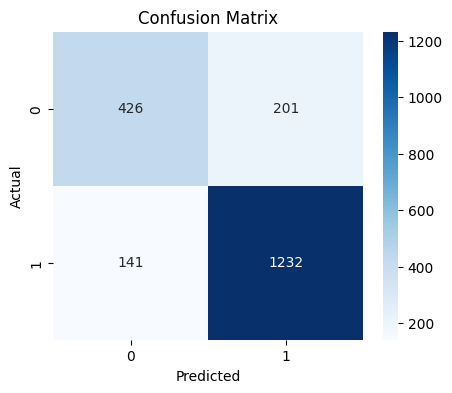

In [22]:
# 🔳 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<a id="top-words"></a>  
#### 🔍 Top Words by Class


In [23]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Only works for linear models with coef_ attribute
coefs = best_model.coef_

# Binary classification
if coefs.shape[0] == 1:
    coefs = coefs.flatten()
    top_pos = np.argsort(coefs)[-10:][::-1]
    top_neg = np.argsort(coefs)[:10]
    
    print("🔵 Top Positive Words:")
    for i in top_pos:
        print(f"{feature_names[i]:<15}  coef: {coefs[i]:.3f}")
    
    print("\n🔴 Top Negative Words:")
    for i in top_neg:
        print(f"{feature_names[i]:<15}  coef: {coefs[i]:.3f}")

# Multiclass classification
else:
    for class_index, class_label in enumerate(best_model.classes_):
        print(f"\n📚 Top words for class: {class_label}")
        top_indices = np.argsort(coefs[class_index])[-10:][::-1]
        for i in top_indices:
            print(f"{feature_names[i]:<15}  coef: {coefs[class_index][i]:.3f}")


🔵 Top Positive Words:
fantast          coef: 1.771
slightli         coef: 1.514
perfect          coef: 1.429
amaz             coef: 1.423
delici           coef: 1.412
excel            coef: 1.374
worri            coef: 1.322
sooo             coef: 1.252
bubbl            coef: 1.177
peanut           coef: 1.156

🔴 Top Negative Words:
overpr           coef: -2.193
mediocr          coef: -1.809
bland            coef: -1.751
elsewher         coef: -1.674
meh              coef: -1.623
horribl          coef: -1.623
wouldnt          coef: -1.557
okay             coef: -1.513
rude             coef: -1.502
terribl          coef: -1.481


<a id="misclassified"></a>  
#### 🤯 Misclassifications


In [24]:
# Create a DataFrame for easy comparison
eval_df = df.loc[y_test.index].copy()
eval_df["predicted"] = y_pred
eval_df["correct"] = eval_df["label"] == eval_df["predicted"]

# Show misclassified rows
misclassified = eval_df[~eval_df["correct"]][["text", "label", "predicted"]]

print(f"❌ Total Misclassified Samples: {len(misclassified)}\n")
display(misclassified.head(10))  # Show first 10 misclassifications


❌ Total Misclassified Samples: 342



,text,label,predicted
8834,like bamboo club doesnt seem bode well purist american spin chine food dish work well other much struggl fierc addict panda express refer time time feel im justifi time bamboo club like delux version panda express fact best dish also orang chicken done much tast greasi counterpart littl overpr consid offer semiglorifi mall food bad,0,1
1624,great coffe shop tasti lunch dinner option good coffe cozi atmospher coupl critiqu found lunch dinner menu bit overpr receiv frequent stop earli morn coffe muffin live area muffin excel uniqu tasti avail doesnt seem like pastri chef begin earli enough morn pastri readi go around 630 7am nich coffe shop ive phoenix area fresh bake good readi go earli earli commut like,0,1
4430,approach front build instantli impress theatric light outsid build foyer larg rubi red creat grand mood walk even larg crystal chandeli theater nice size larg sit medium scale seat christma product nutcrack third row center view nice didnt seem room live band orchestra sound system full,0,1
2776,great hurri slice salad readi go averag qualiti nice open space perfect stop catch movi next door,0,1
4144,wife stay transit arizona enjoy stay hotel seem modern current renov place far good improv,0,1
1029,tough time decid 4 5 star wish 45 star avail choos went busi trip cowork tri least one follow sapporo ever bad serv cold thumb green tea good good servic refil also edamam good right amount salt miso interest wooden bowl wooden spoon tast good tho yellow tail salmon tuna albacor uni fw eel kampachi nigiri good stuff also yasu style nigiri type good usual involv ponzu top spici tuna softshel crab roll ssc great servic pretti good sushi also good bar full wish could eaten sushi chef friendli talk peopl bar unusu least compar la base qualiti fish outsid whatev ponzu soy wasabi ingredi pretti good wouldnt say 5 star sinc gener judg place wholli food give 45 fail round,1,0
4958,pretti yum friend decid bike last saturday afternoon one place ventur drunken geisha happi hour delici other grab food didnt hear complaint server awesom even put last round drink hold happi hour price extrem kind nice patio great happi hour price p would come regular price hour,1,0
8530,great korean kalbi tabl top meat rest dish wasnt impress weekend could realli busi might need wait get food weekday pretti slow like korean bbq best place chandler gilbert area,1,0
8814,decid break routin get haircut local great clip call ahead ask experienc barber could flat top ladi assur leari say least sat chair 20 someth fibbertygibbet dress like madonna half way butcher ask advic advic owner accomplish haircut kid inch longer side center look like cross gunni flock seagul went home set clipper 3 finish jobwould go back unless lost bet,0,1
2645,talk option almost unfair mani item menu especi food good gone cheesecak factori sever time abl even put dent menu wasnt hungri time decid order small plate menu start corn fritter order shrimp grit husband order hibachi steak reason didnt give five star didnt get appet food readi time alreadi stuf face bread butter delici server apolog delay bring app manag came didnt charg u corn fritter much appreci one fritter sinc dish front u didnt want get cold realli like shrimp grit think dish came littl much saucebut that mei realli like tast cheddar grit husband steak realli realli good hibachi steak normal order go back,1,0


<a id="new-texts"></a>  
#### ✍️ Predict on New Text


In [27]:
# ✅ Select the best model by name
best_model = models[best_model_name]

# ✍️ Sample cleaned texts (already lowercased etc.)
new_texts = [
    "absolutely love experience would come again",
    "worst service ever not coming back",
    "okay not great but not terrible either",
    "food delicious staff friendly",
    "wait time long food cold disappointed overall"
]

# 🔠 Vectorize using the same fitted vectorizer
X_text_new = vectorizer.transform(new_texts)

# 🧠 Extract POS + NER features for new texts
new_pos = [extract_pos_features(text) for text in new_texts]
new_ner = [extract_ner_features(text) for text in new_texts]
new_ling_df = pd.DataFrame(new_pos).add(pd.DataFrame(new_ner), fill_value=0).fillna(0)

# ⚠️ Ensure column order matches training features
new_ling_df = new_ling_df.reindex(columns=linguistic_features.columns, fill_value=0)

X_ling_new = sparse.csr_matrix(new_ling_df.values)

# 🧱 Combine text + linguistic features
X_new = hstack([X_text_new, X_ling_new])

# 🤖 Predict
preds = best_model.predict(X_new)

# 📄 Display results
for text, label in zip(new_texts, preds):
    print(f"Text: {text}\nPredicted Sentiment: {label}\n---")

Text: absolutely love experience would come again
Predicted Sentiment: 1
---
Text: worst service ever not coming back
Predicted Sentiment: 0
---
Text: okay not great but not terrible either
Predicted Sentiment: 0
---
Text: food delicious staff friendly
Predicted Sentiment: 1
---
Text: wait time long food cold disappointed overall
Predicted Sentiment: 1
---


[Back to the top](#table-of-contents)
___
